# Convolutional Neural Networks: Application (PyTorch 版本)

欢迎来到第四课的第二个作业！本 notebook 保留原作业的主题顺序和教学目标，但将 TensorFlow/Keras 代码替换为 PyTorch。你将完成：

- 使用 `torch.nn.Sequential` 创建手语数字六分类模型；
- 使用自定义 `nn.Module` 的函数式 `forward` 构建手语数字多分类模型；
- 理解卷积层、池化层、Batch Normalization、Flatten 和全连接层；
- 使用 PyTorch 的 `DataLoader`、损失函数、优化器和训练循环完成训练。

**完成本作业后，你应能够：**

- 使用 PyTorch 构建并训练六分类 CNN；
- 使用 PyTorch 构建并训练多分类 CNN；
- 理解 Sequential 模型与自定义 `nn.Module` 的适用场景；
- 理解 PyTorch 中 logits、`Softmax`、`CrossEntropyLoss` 之间的关系。

本版本适合学习和运行，不再针对 Coursera 的 TensorFlow AutoGrader。

## 目录

- [1 - 导入包](#1)
    - [1.1 - 加载数据并划分训练集/测试集](#1-1)
- [2 - PyTorch 中的层](#2)
- [3 - Sequential API](#3)
    - [3.1 - 创建 Sequential 模型](#3-1)
        - [练习 1 - sequential_sign_model](#ex-1)
    - [3.2 - 训练和评估模型](#3-2)
- [4 - 自定义 Module 与函数式 forward](#4)
    - [4.1 - 加载 SIGNS 数据集](#4-1)
    - [4.2 - 划分训练集/测试集](#4-2)
    - [4.3 - 前向传播](#4-3)
        - [练习 2 - convolutional_model](#ex-2)
    - [4.4 - 训练模型](#4-4)
- [5 - History 字典](#5)
- [6 - 参考资料](#6)

<a name='1'></a>
## 1 - 导入包

首先导入数据处理、绘图和 PyTorch 所需的包。

In [1]:
import math
import random
import numpy as np
# 使用非 GUI 后端，避免 plt.show() 等待外部窗口的事件循环。
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Image as NotebookImage
from PIL import Image as PILImage
from io import BytesIO

def display_figure(fig):
    """将 Matplotlib 图像作为 PNG 内嵌到 notebook，无需打开窗口。"""
    try:
        with BytesIO() as buffer:
            fig.savefig(buffer, format="png", bbox_inches="tight")
            display(NotebookImage(data=buffer.getvalue()))
    finally:
        plt.close(fig)
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import h5py

def load_signs_dataset():
    """读取本地手语数据，不依赖 TensorFlow。"""
    with h5py.File("datasets/train_signs.h5", "r") as f:
        x_train, y_train = f["train_set_x"][:], f["train_set_y"][:].reshape(1, -1)
    with h5py.File("datasets/test_signs.h5", "r") as f:
        x_test, y_test = f["test_set_x"][:], f["test_set_y"][:].reshape(1, -1)
        classes = f["list_classes"][:]
    return x_train, y_train, x_test, y_test, classes

SEED = 1
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


def images_to_tensor(x):
    """将课程数据的 NHWC 格式转换为 PyTorch 使用的 NCHW 格式。"""
    return torch.tensor(x, dtype=torch.float32).permute(0, 3, 1, 2)


def class_labels_to_tensor(y):
    return torch.tensor(np.asarray(y).reshape(-1), dtype=torch.long)


def model_summary(model, input_shape):
    """一个轻量的 PyTorch 模型检查器，对应 Keras 的 model.summary()。"""
    print(model)
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    was_training = model.training
    model.eval()
    with torch.no_grad():
        dummy = torch.zeros(1, *input_shape, device=device)
        output = model(dummy)
    model.train(was_training)
    print(f"input shape : {(1, *input_shape)}")
    print(f"output shape: {tuple(output.shape)}")
    print(f"parameters  : {total:,} (trainable: {trainable:,})")


def evaluate_multiclass(model, loader, criterion):
    model.eval()
    loss_sum = 0.0
    correct = 0
    count = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss_sum += criterion(logits, yb).item() * xb.size(0)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            count += xb.size(0)
    return loss_sum / count, correct / count


def train_multiclass(model, train_loader, test_loader, epochs=100, lr=1e-3):
    # CrossEntropyLoss 内部已经包含 LogSoftmax，因此模型输出 logits 即可。
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}
    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        train_loss, train_acc = evaluate_multiclass(model, train_loader, criterion)
        val_loss, val_acc = evaluate_multiclass(model, test_loader, criterion)
        history["loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)
        if epoch == 0 or (epoch + 1) % 10 == 0 or epoch == epochs - 1:
            print(f"epoch {epoch + 1:03d}/{epochs} - loss: {train_loss:.4f} - accuracy: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")
    return history


device: cuda


<a name='1-1'></a>
### 1.1 - 加载数据并划分训练集/测试集

使用本地 SIGNS 数据集，标签为 0～5。两个模型均完成手语六分类。图像转为 NCHW，标签为 (N,) 的 torch.long 整数，不使用 one-hot。

遇到 CUDA 断言后，请先重启内核，再从头运行。


In [2]:
X_train_orig, Y_train_orig, X_test_orig, Y_test_orig, classes = load_signs_dataset()

X_train = images_to_tensor(X_train_orig / 255.)
X_test = images_to_tensor(X_test_orig / 255.)
Y_train = class_labels_to_tensor(Y_train_orig)
Y_test = class_labels_to_tensor(Y_test_orig)

print("number of training examples =", X_train.shape[0])
print("number of test examples =", X_test.shape[0])
print("X_train shape =", tuple(X_train.shape))
print("Y_train shape =", tuple(Y_train.shape))
print("X_test shape =", tuple(X_test.shape))
print("Y_test shape =", tuple(Y_test.shape))

assert Y_train.dtype == torch.long
assert Y_train.ndim == 1
assert ((Y_train >= 0) & (Y_train < 6)).all()
assert ((Y_test >= 0) & (Y_test < 6)).all()
print("label values:", torch.unique(Y_train))


number of training examples = 1080
number of test examples = 120
X_train shape = (1080, 3, 64, 64)
Y_train shape = (1080,)
X_test shape = (120, 3, 64, 64)
Y_test shape = (120,)
label values: tensor([0, 1, 2, 3, 4, 5])


你可以显示数据集中的图片。绘图时使用原始的 NHWC 图片，送入 PyTorch 模型时则需要转换为 NCHW。

label = 0


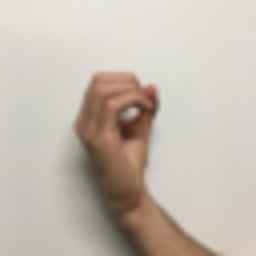

In [3]:
index = 124
# 原始数据是 uint8 RGB 图像，直接内嵌显示，不调用 plt.show()。
print("label =", int(np.asarray(Y_train_orig).reshape(-1)[index]))
display(PILImage.fromarray(X_train_orig[index]).resize((256, 256)))


<a name='2'></a>
## 2 - PyTorch 中的层

PyTorch 的每一层通常是 `torch.nn.Module` 的一个对象。层接收输入张量并返回输出张量，多个层可以组合成一个更大的模型。常用的 CNN 层包括 `nn.Conv2d`、`nn.BatchNorm2d`、`nn.ReLU`、`nn.MaxPool2d`、`nn.Flatten` 和 `nn.Linear`。

<a name='3'></a>
## 3 - Sequential API

`nn.Sequential` 适合数据沿着一条直线依次流过各层的模型。它可以把多个层按顺序组合起来，代码简洁，适合本节的手语数字六分类模型。

如果网络存在分支、跳跃连接、多输入或多输出，就应该定义自定义的 `nn.Module`，并在 `forward()` 中显式描述数据流。

<a name='3-1'></a>
### 3.1 - 创建 Sequential 模型

<a name='ex-1'></a>
### 练习 1 - sequential_sign_model

实现 `sequential_sign_model`，构建下面的模型：

```text
ZEROPAD2D → CONV2D → BATCHNORM → RELU → MAXPOOL → FLATTEN → DENSE
```

参数设置：

- `ZeroPad2d`：四周填充 3，输入大小为 `64 x 64 x 3`；
- `Conv2d`：32 个 `7 x 7` 卷积核，stride 为 1；
- `BatchNorm2d`：对 32 个输出通道进行归一化；
- `ReLU`；
- `MaxPool2d`：使用默认的 `2 x 2` 窗口和 stride 2；
- `Flatten`；
- `Linear`：输出 6 个 logits，对应数字 0～5，训练时不添加 Sigmoid 或 Softmax。

In [4]:
# Exercise 1: sequential_sign_model

def sequential_sign_model():
    """
    ZEROPAD2D -> CONV2D -> BATCHNORM -> RELU -> MAXPOOL -> FLATTEN -> DENSE
    """
    model = nn.Sequential(
        nn.ZeroPad2d(3),
        nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7, stride=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Flatten(),
        nn.Linear(32 * 32 * 32, 6),
    )
    return model


In [5]:
sequential_model = sequential_sign_model().to(device)
model_summary(sequential_model, (3, 64, 64))


Sequential(
  (0): ZeroPad2d((3, 3, 3, 3))
  (1): Conv2d(3, 32, kernel_size=(7, 7), stride=(1, 1))
  (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): ReLU()
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Flatten(start_dim=1, end_dim=-1)
  (6): Linear(in_features=32768, out_features=6, bias=True)
)
input shape : (1, 3, 64, 64)
output shape: (1, 6)
parameters  : 201,414 (trainable: 201,414)


模型输出 (N, 6) 的 logits，标签为 (N,) 的整数类别（0～5）。使用 nn.CrossEntropyLoss()，模型末尾不添加 Sigmoid 或 Softmax。需要预测概率时使用 torch.softmax(logits, dim=1)。


In [6]:
# 将训练数据 X_train 和标签 Y_train 打包成 TensorDataset，
# 再用 DataLoader 按 batch_size=16 分批读取，并在每个 epoch 打乱训练数据顺序
sequential_train_loader = DataLoader(
    TensorDataset(X_train, Y_train),
    batch_size=16,
    shuffle=True
)

# 将测试数据 X_test 和标签 Y_test 打包成 DataLoader
# 测试集不需要打乱顺序，所以 shuffle=False
sequential_test_loader = DataLoader(
    TensorDataset(X_test, Y_test),
    batch_size=16,
    shuffle=False
)

# 定义六分类交叉熵损失函数
# 模型输出 6 个 logits，标签为 0~5 的整数，不添加 Sigmoid 或 Softmax
criterion = nn.CrossEntropyLoss()

# 使用 Adam 优化器更新 sequential_model 的参数
# lr=1e-3 表示学习率为 0.001
optimizer = torch.optim.Adam(
    sequential_model.parameters(),
    lr=1e-3
)

# 打印损失函数和优化器，确认创建成功
print(criterion)
print(optimizer)

CrossEntropyLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


可以通过打印模型结构、输入输出形状和参数数量，检查模型是否符合预期。`model_summary` 是本 notebook 提供的轻量检查函数。

In [7]:
model_summary(sequential_model, (3, 64, 64))


Sequential(
  (0): ZeroPad2d((3, 3, 3, 3))
  (1): Conv2d(3, 32, kernel_size=(7, 7), stride=(1, 1))
  (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): ReLU()
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Flatten(start_dim=1, end_dim=-1)
  (6): Linear(in_features=32768, out_features=6, bias=True)
)
input shape : (1, 3, 64, 64)
output shape: (1, 6)
parameters  : 201,414 (trainable: 201,414)


<a name='3-2'></a>
### 3.2 - 训练和评估模型

PyTorch 不会自动替你执行 `.fit()`。训练循环通常包含以下步骤：

1. 从 `DataLoader` 读取一个 minibatch；
2. 前向传播得到预测值；
3. 计算 loss；
4. 调用 `loss.backward()` 计算梯度；
5. 调用 `optimizer.step()` 更新参数；
6. 调用 `optimizer.zero_grad()` 清空上一批次的梯度。

In [8]:
sequential_history = train_multiclass(sequential_model, sequential_train_loader, sequential_test_loader, epochs=10, lr=1e-3)


epoch 001/10 - loss: 1.9581 - accuracy: 0.5731 - val_loss: 2.4350 - val_accuracy: 0.5083
epoch 010/10 - loss: 0.0013 - accuracy: 1.0000 - val_loss: 0.1858 - val_accuracy: 0.9417


训练完成后，在评估阶段使用 `model.eval()` 和 `torch.no_grad()`，关闭 BatchNorm 的训练行为并避免保存梯度。

In [9]:
sequential_test_loss, sequential_test_accuracy = evaluate_multiclass(sequential_model, sequential_test_loader, nn.CrossEntropyLoss())
print(f"test loss = {sequential_test_loss:.4f}, test accuracy = {sequential_test_accuracy:.4f}")


test loss = 0.1858, test accuracy = 0.9417


虽然 `nn.Sequential` 很方便，但它只能表达线性的层连接。对于共享层、分支、跳跃连接或多输入多输出模型，需要使用自定义 `nn.Module`，在 `forward()` 中定义更灵活的数据流。

<a name='4'></a>
## 4 - 自定义 Module 与函数式 forward

这一部分使用更灵活的 PyTorch 模型写法，构建一个能够识别 6 个手语数字的卷积网络。PyTorch 中没有与 Keras Functional API 完全同名的接口，但自定义 `nn.Module` 的 `forward()` 可以清晰地表达同样的计算图思想。

- Sequential：层按照固定顺序连接；
- 自定义 Module：可以在 `forward()` 中使用分支、共享层和跳跃连接；
- PyTorch 的模型结构是在实际执行 `forward()` 时计算的。

<a name='4-1'></a>
### 4.1 - 加载 SIGNS 数据集

SIGNS 数据集包含代表数字 0 到 5 的 6 类手语图片。

In [10]:
X_train_orig, Y_train_orig, X_test_orig, Y_test_orig, classes = load_signs_dataset()


下面显示一张带标签的图片。可以修改 `index` 来查看其他样本。

label = 4


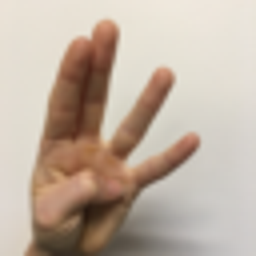

In [11]:
index = 9
print("label =", int(np.asarray(Y_train_orig).reshape(-1)[index]))
display(PILImage.fromarray(X_train_orig[index]).resize((256, 256)))


<a name='4-2'></a>
### 4.2 - 划分训练集/测试集

由于输入是图像，使用 CNN 比全连接网络更自然。下面进行归一化，并将 NHWC 转为 PyTorch 的 NCHW。

注意：PyTorch 的 `CrossEntropyLoss` 需要类别索引标签，例如 `0, 1, ..., 5`，不需要 one-hot 标签。

In [12]:
X_train = images_to_tensor(X_train_orig / 255.)
X_test = images_to_tensor(X_test_orig / 255.)
Y_train = class_labels_to_tensor(Y_train_orig)
Y_test = class_labels_to_tensor(Y_test_orig)

print("number of training examples =", X_train.shape[0])
print("number of test examples =", X_test.shape[0])
print("X_train shape =", tuple(X_train.shape))
print("Y_train shape =", tuple(Y_train.shape))
print("X_test shape =", tuple(X_test.shape))
print("Y_test shape =", tuple(Y_test.shape))

assert Y_train.dtype == torch.long
assert Y_train.ndim == 1
assert ((Y_train >= 0) & (Y_train < 6)).all()
assert ((Y_test >= 0) & (Y_test < 6)).all()
print("label values:", torch.unique(Y_train))


number of training examples = 1080
number of test examples = 120
X_train shape = (1080, 3, 64, 64)
Y_train shape = (1080,)
X_test shape = (120, 3, 64, 64)
Y_test shape = (120,)
label values: tensor([0, 1, 2, 3, 4, 5])


<a name='4-3'></a>
### 4.3 - 前向传播

下面的模型包含：

```text
CONV2D → RELU → MAXPOOL → CONV2D → RELU → MAXPOOL → FLATTEN → LINEAR
```

我们使用自定义 `nn.Module`，并在 `forward()` 中逐步计算。

- `nn.Conv2d` 完成卷积；
- `nn.ReLU` 完成逐元素 ReLU；
- `nn.MaxPool2d` 完成最大池化；
- `nn.Flatten` 将每个样本展平；
- `nn.Linear` 完成全连接映射。

原 Keras 版本最后使用 Softmax，而 PyTorch 的 `CrossEntropyLoss` 内部已经包含 LogSoftmax，因此模型最后应返回未归一化的 logits，不要在模型中额外添加 Softmax。

#### Window、kernel、filter、pool

在卷积中，kernel/filter 通常指卷积核。池化使用一个窗口在特征图上滑动，并对窗口内的值取最大值或平均值。

本模型中的 `same` 卷积使用显式的非对称 Zero Padding 来匹配 TensorFlow 的输出尺寸：偶数大小的卷积核无法只用一个对称 padding 完全复现 `same`，因此需要在上下或左右多填充一个像素。

<a name='ex-2'></a>
### 练习 2 - convolutional_model

实现 `convolutional_model`，构建以下模型：

```text
CONV2D → RELU → MAXPOOL → CONV2D → RELU → MAXPOOL → FLATTEN → LINEAR
```

参数设置：

- 第一层：8 个 `4 x 4` 滤波器，stride 为 1，`same` padding；
- 第一个池化层：`8 x 8` 窗口，stride 为 8；
- 第二层：16 个 `2 x 2` 滤波器，stride 为 1，`same` padding；
- 第二个池化层：`4 x 4` 窗口，stride 为 4；
- 展平后连接到 6 个输出神经元。

In [13]:
# Exercise 2: convolutional_model

# 继承 nn.Module，定义一个自定义神经网络
class SignConvNet(nn.Module):
    def __init__(self, input_shape):
        # 初始化父类，让 PyTorch 能够管理本模型的层和参数
        super().__init__()

        # 单张图片的形状：(通道数, 高度, 宽度)
        # 本例为 (3, 64, 64)，注意不是 TensorFlow 的 (64, 64, 3)
        channels, height, width = input_shape

        # ---------- 第一组：卷积 + ReLU + 池化 ----------

        # ZeroPad2d 的参数顺序是：(左, 右, 上, 下)
        #
        # 4×4 卷积核、stride=1，要保持输出宽高不变：
        # 每个方向需要的总填充量为 4-1=3
        # 因为 3 不能平均分到两边，所以采用不对称填充：
        # 左边/上边补 1，右边/下边补 2
        #
        # (N, 3, 64, 64) → (N, 3, 67, 67)
        self.pad1 = nn.ZeroPad2d((1, 2, 1, 2))

        # 输入通道为 channels，输出通道为 8
        # 即使用 8 个大小为 4×4×channels 的卷积核
        # padding 默认为 0，因为前面已经手动填充
        #
        # 输出空间尺寸：(67-4)/1+1 = 64
        # (N, 3, 67, 67) → (N, 8, 64, 64)
        self.conv1 = nn.Conv2d(
            in_channels=channels,
            out_channels=8,
            kernel_size=4,
            stride=1
        )

        # ReLU(x) = max(0, x)
        # 引入非线性，不改变张量形状
        self.relu1 = nn.ReLU()

        # 对每个通道分别做最大池化
        # 每次在 8×8 区域内取最大值，窗口移动 8 个像素
        #
        # 输出空间尺寸：(64-8)/8+1 = 8
        # (N, 8, 64, 64) → (N, 8, 8, 8)
        self.pool1 = nn.MaxPool2d(kernel_size=8, stride=8)

        # ---------- 第二组：卷积 + ReLU + 池化 ----------

        # 2×2 卷积核、stride=1，要保持输出宽高不变：
        # 每个方向需要的总填充量为 2-1=1
        # 因此只在右侧和下侧各补 1 个像素
        #
        # (N, 8, 8, 8) → (N, 8, 9, 9)
        self.pad2 = nn.ZeroPad2d((0, 1, 0, 1))

        # 使用 16 个大小为 2×2×8 的卷积核
        # 输入通道数必须与上一层的输出通道数一致
        #
        # 输出空间尺寸：(9-2)/1+1 = 8
        # (N, 8, 9, 9) → (N, 16, 8, 8)
        self.conv2 = nn.Conv2d(
            in_channels=8,
            out_channels=16,
            kernel_size=2,
            stride=1
        )

        # 再次引入非线性，不改变形状
        self.relu2 = nn.ReLU()

        # 使用 4×4 窗口、stride=4 进行最大池化
        #
        # 输出空间尺寸：(8-4)/4+1 = 2
        # (N, 16, 8, 8) → (N, 16, 2, 2)
        self.pool2 = nn.MaxPool2d(kernel_size=4, stride=4)

        # ---------- 分类部分 ----------

        # 默认从第 1 维开始展平，保留第 0 维的批次维度 N
        # 每张图片包含 16×2×2 = 64 个特征
        #
        # (N, 16, 2, 2) → (N, 64)
        self.flatten = nn.Flatten()

        # 将 64 个特征映射为 6 个类别分数
        # 分别对应手语数字 0、1、2、3、4、5
        #
        # (N, 64) → (N, 6)
        # 注意：输入特征数写死为 64，不能直接支持任意图片尺寸
        self.fc = nn.Linear(16 * 2 * 2, 6)

    def forward(self, x):
        # 定义实际的前向传播顺序
        # 调用 model(x) 时，PyTorch 会自动执行这个方法

        # 第一组：填充 → 卷积 → ReLU → 最大池化
        x = self.pad1(x)                # (N, 3, 67, 67)
        x = self.relu1(self.conv1(x))   # (N, 8, 64, 64)
        x = self.pool1(x)               # (N, 8, 8, 8)

        # 第二组：填充 → 卷积 → ReLU → 最大池化
        x = self.pad2(x)                # (N, 8, 9, 9)
        x = self.relu2(self.conv2(x))    # (N, 16, 8, 8)
        x = self.pool2(x)               # (N, 16, 2, 2)

        # 将特征图展平为特征向量
        x = self.flatten(x)            # (N, 64)

        # 输出 6 个未经归一化的类别分数，也叫 logits
        # CrossEntropyLoss 接收 logits，训练时不要先调用 Softmax
        return self.fc(x)              # (N, 6)


def convolutional_model(input_shape):
    # 创建并返回模型实例，此时只完成初始化，还没有训练
    # 示例：model = convolutional_model((3, 64, 64))
    return SignConvNet(input_shape)

In [14]:
conv_model = convolutional_model((3, 64, 64)).to(device)
model_summary(conv_model, (3, 64, 64))
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(conv_model.parameters(), lr=1e-3)
print(criterion)
print(optimizer)


SignConvNet(
  (pad1): ZeroPad2d((1, 2, 1, 2))
  (conv1): Conv2d(3, 8, kernel_size=(4, 4), stride=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=8, stride=8, padding=0, dilation=1, ceil_mode=False)
  (pad2): ZeroPad2d((0, 1, 0, 1))
  (conv2): Conv2d(8, 16, kernel_size=(2, 2), stride=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=64, out_features=6, bias=True)
)
input shape : (1, 3, 64, 64)
output shape: (1, 6)
parameters  : 1,310 (trainable: 1,310)
CrossEntropyLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


Sequential 和自定义 `nn.Module` 都会返回一个可以训练的 PyTorch 模型对象。区别在于：Sequential 只能表达线性层堆叠，而自定义 Module 可以在 `forward()` 中表达任意计算图。

<a name='4-4'></a>
### 4.4 - 训练模型

使用 `DataLoader` 以 minibatch 形式读取数据，并通过显式训练循环更新参数。

In [15]:
sign_train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=64, shuffle=True)
sign_test_loader = DataLoader(TensorDataset(X_test, Y_test), batch_size=64, shuffle=False)
history = train_multiclass(conv_model, sign_train_loader, sign_test_loader, epochs=100, lr=1e-3)


epoch 001/100 - loss: 1.7933 - accuracy: 0.1667 - val_loss: 1.7931 - val_accuracy: 0.1667
epoch 010/100 - loss: 1.6720 - accuracy: 0.5111 - val_loss: 1.6911 - val_accuracy: 0.4417
epoch 020/100 - loss: 1.1372 - accuracy: 0.6269 - val_loss: 1.1924 - val_accuracy: 0.5000
epoch 030/100 - loss: 0.8680 - accuracy: 0.7231 - val_loss: 0.9332 - val_accuracy: 0.6750
epoch 040/100 - loss: 0.7586 - accuracy: 0.7537 - val_loss: 0.8441 - val_accuracy: 0.6583
epoch 050/100 - loss: 0.6278 - accuracy: 0.7917 - val_loss: 0.7074 - val_accuracy: 0.7417
epoch 060/100 - loss: 0.5588 - accuracy: 0.8250 - val_loss: 0.6269 - val_accuracy: 0.7750
epoch 070/100 - loss: 0.5004 - accuracy: 0.8528 - val_loss: 0.5859 - val_accuracy: 0.8000
epoch 080/100 - loss: 0.4934 - accuracy: 0.8343 - val_loss: 0.5846 - val_accuracy: 0.7583
epoch 090/100 - loss: 0.4248 - accuracy: 0.8639 - val_loss: 0.5003 - val_accuracy: 0.8000
epoch 100/100 - loss: 0.3930 - accuracy: 0.8787 - val_loss: 0.4950 - val_accuracy: 0.8417


<a name='5'></a>
## 5 - History 字典

PyTorch 不会自动返回 Keras 风格的 History 对象。本 notebook 在训练循环中手动把每个 epoch 的 loss 和 accuracy 保存到 `history` 字典中：

In [16]:
history


{'loss': [1.7933219971480192,
  1.7907317382318002,
  1.7881128655539618,
  1.7848809798558554,
  1.7807686938179863,
  1.774553863207499,
  1.7622894613831133,
  1.744665484075193,
  1.7135238762255067,
  1.6720150179333158,
  1.6216063914475618,
  1.562223196029663,
  1.4936940696504382,
  1.4286622992268314,
  1.3644494895581847,
  1.3126849792621753,
  1.262687341372172,
  1.2213982529110379,
  1.182038912066707,
  1.1372343496040063,
  1.1000876673945674,
  1.0643566149252432,
  1.033784102510523,
  1.0081164368876705,
  0.9945478660088999,
  0.9497063725082963,
  0.9320079353120592,
  0.9125866775159482,
  0.8921983780684295,
  0.8680151100511904,
  0.8682963477240668,
  0.8362386663754781,
  0.8494103524419997,
  0.8330988009770711,
  0.7984293385788247,
  0.7775001945318999,
  0.7648497338648196,
  0.745600422223409,
  0.7383188675951075,
  0.7585906885288379,
  0.7251248558362325,
  0.7043479164441426,
  0.6994554969999526,
  0.675142130586836,
  0.6805382838955631,
  0.671722

下面可视化训练集和测试集上的 loss 与 accuracy。

In [ ]:
# 独立使用 Agg 画布，不经过 pandas.plot、pyplot 或旧的 display_figure。
# 如果第一条消息都不出现，单元可能在等待前面的训练执行完毕。
print("[1/4] Plot cell started", flush=True)
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg
from IPython.display import display, Image as NotebookImage
from io import BytesIO
import math

# 后半部分训练使用 history；若要查看前半部分，改成 sequential_history。
plot_history = history
keys = ("loss", "val_loss", "accuracy", "val_accuracy")
series = {key: [float(v) for v in plot_history[key]] for key in keys}
count = len(series["loss"])
if count == 0 or any(len(values) != count for values in series.values()):
    raise ValueError("History must contain nonempty, equally sized metric lists.")
if not all(math.isfinite(v) for values in series.values() for v in values):
    raise ValueError("History contains NaN or infinity; check training first.")
epochs = list(range(1, count + 1))
print(f"[2/4] Validated {count} epochs", flush=True)

for step, (train_key, val_key, title, ylabel) in enumerate([
    ("loss", "val_loss", "Model loss", "Loss"),
    ("accuracy", "val_accuracy", "Model accuracy", "Accuracy"),
], start=3):
    fig = Figure(figsize=(8, 4), dpi=100)
    canvas = FigureCanvasAgg(fig)
    ax = fig.subplots()
    ax.plot(epochs, series[train_key], label="train")
    ax.plot(epochs, series[val_key], label="validation")
    ax.set(title=title, xlabel="Epoch", ylabel=ylabel)
    ax.legend()
    ax.grid(alpha=0.3)
    with BytesIO() as buffer:
        canvas.print_png(buffer)
        png = buffer.getvalue()
    print(f"[{step}/4] {title}: PNG ready ({len(png)} bytes)", flush=True)
    display(NotebookImage(data=png))
    fig.clear()
print("Plot cell finished", flush=True)


[1/4] Plot cell started
[2/4] Validated 100 epochs


两种模型均完成手语六分类：nn.Sequential 和自定义 nn.Module 都输出 6 个 logits，使用整数标签与 CrossEntropyLoss，以 argmax(dim=1) 得到预测类别。


<a name='6'></a>
## 6 - 参考资料

建议阅读 PyTorch 官方文档：

- [torch.nn](https://pytorch.org/docs/stable/nn.html)
- [torch.nn.Conv2d](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)
- [torch.nn.Sequential](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html)
- [torch.utils.data.DataLoader](https://pytorch.org/docs/stable/data.html)
- [Training a classifier](https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html)